In [140]:
import sys

print("Python executable being used:")
print(sys.executable)

!{sys.executable} -m pip install pylatexenc matplotlib

Python executable being used:
c:\python314\python.exe
Defaulting to user installation because normal site-packages is not writeable


## Problem 1: Generating Random Boolean Functions

The Deutsch–Jozsa algorithm operates on Boolean functions that take a fixed number of inputs and return a single Boolean output. These functions are guaranteed to be either **constant** or **balanced**.

- A **constant function** returns the same output (`True` or `False`) for all possible input combinations.
- A **balanced function** returns `True` for exactly half of the possible inputs and `False` for the other half.

For a function with four Boolean inputs, there are \(2^4 = 16\) possible input combinations. Therefore:
- A constant function returns the same value for all 16 inputs.
- A balanced function returns `True` for exactly 8 inputs and `False` for the remaining 8.

In this task, we construct a function `random_constant_balanced` that randomly generates and returns either a constant or balanced Boolean function. The implementation ensures correctness by either:
- selecting a single output value for all inputs (constant), or  
- randomly choosing 8 input combinations that map to `True` (balanced).

In [141]:
import random
import itertools



def random_constant_balanced():
    """
    Returns a randomly chosen function f(a, b, c, d)
    that is either constant or balanced.
    """

    # All 16 possible inputs
    inputs = list(itertools.product([False, True], repeat=4))

    # Randomly decide function type
    function_type = random.choice(["constant", "balanced"])

    if function_type == "constant":
        value = random.choice([True, False])

        def f(a, b, c, d):
            return value

        return f

    else:
        # Choose 8 inputs that return True
        true_inputs = set(random.sample(inputs, 8))

        def f(a, b, c, d):
            return (a, b, c, d) in true_inputs

        return f

In [142]:
f = random_constant_balanced()

results = []
for a, b, c, d in itertools.product([False, True], repeat=4):
    results.append(f(a, b, c, d))

print("True count:", sum(results))

True count: 8


## Problem 2: Determining if a Boolean Function is Constant or Balanced

To determine whether a Boolean function is constant or balanced using a classical approach, we must evaluate the function on different input combinations and observe the outputs.

For a function with four Boolean inputs, there are \(2^4 = 16\) possible input combinations.

- A **constant function** returns the same output for all inputs.
- A **balanced function** returns `True` for exactly 8 inputs and `False` for the remaining 8.

In the worst case, we must evaluate the function on all 16 inputs to be completely certain of its type. This is because a function may appear constant for many inputs before revealing a differing output.

This highlights the classical computational cost of the problem, which the Deutsch–Jozsa algorithm improves upon using quantum computation.

In [143]:
import itertools

def determine_constant_balanced(f):
    """
    Determine whether a Boolean function f(a, b, c, d) is
    constant or balanced.

    Args:
        f (function): A function taking four Boolean inputs.

    Returns:
        str: "constant" or "balanced"
    """

    # Generate all possible inputs (16 combinations)
    inputs = itertools.product([False, True], repeat=4)

    results = []

    for inp in inputs:
        results.append(f(*inp))

        # Early exit: if we see both True and False, it's balanced
        if True in results and False in results:
            return "balanced"

    # If all outputs are the same, it's constant
    return "constant"#

### Efficiency

In the worst case, we must evaluate the function on all 16 possible inputs to be completely certain whether it is constant or balanced.

This happens when the function is constant, or when a balanced function only reveals differing outputs late in the evaluation.

Therefore, the maximum number of function calls required is **16**.

While the implementation includes an early exit (returning "balanced" as soon as both `True` and `False` are observed), this does not improve the worst-case complexity.

This demonstrates that the classical solution has a worst-case time complexity of \(O(2^n)\) for \(n\) input bits, compared to the Deutsch–Jozsa quantum algorithm, which can solve the problem with a single evaluation.

## Problem 3: Quantum Oracles for Deutsch's Algorithm

Deutsch's algorithm evaluates a Boolean function using a quantum oracle. For a single input bit, there are four possible Boolean functions: two constant and two balanced.

A quantum oracle implements a function \( f(x) \) using the transformation:

\[
U_f |x, y\rangle = |x, y \oplus f(x)\rangle
\]

where \( \oplus \) denotes XOR.

Each oracle is constructed as a quantum circuit that applies specific quantum gates to produce the correct transformation. In this section, we define and demonstrate the four possible oracles corresponding to all single-input Boolean functions.

Defaulting to user installation because normal site-packages is not writeable
f0 (constant 0)


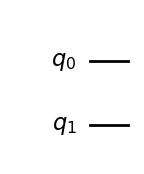

f1 (constant 1)


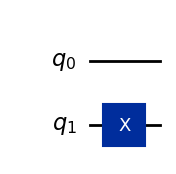

f2 (balanced: f(x)=x)


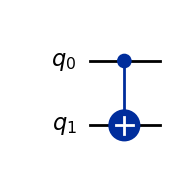

f3 (balanced: f(x)=not x)


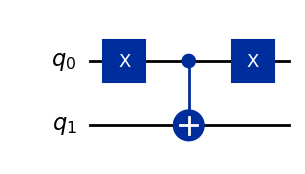

In [144]:
import sys
!{sys.executable} -m pip install matplotlib pylatexenc
from qiskit import QuantumCircuit


# f0: constant 0 → always returns 0 (do nothing)
def oracle_f0():
    qc = QuantumCircuit(2)
    return qc


# f1: constant 1 → always returns 1 (flip output qubit)
def oracle_f1():
    qc = QuantumCircuit(2)
    qc.x(1)  # flip output qubit
    return qc


# f2: balanced → f(x) = x (CNOT)
def oracle_f2():
    qc = QuantumCircuit(2)
    qc.cx(0, 1)  # control = input, target = output
    return qc


# f3: balanced → f(x) = NOT x
def oracle_f3():
    qc = QuantumCircuit(2)
    qc.x(0)
    qc.cx(0, 1)
    qc.x(0)
    return qc


# --- Demonstration ---
oracles = {
    "f0 (constant 0)": oracle_f0(),
    "f1 (constant 1)": oracle_f1(),
    "f2 (balanced: f(x)=x)": oracle_f2(),
    "f3 (balanced: f(x)=not x)": oracle_f3(),
}

for name, circuit in oracles.items():
    print(name)
    display(circuit.draw("mpl"))

### Oracle Explanations

Each oracle implements the transformation \( U_f |x, y\rangle = |x, y \oplus f(x)\rangle \).

- **f₀ (constant 0)**:  
  No gates are applied. Since \( f(x) = 0 \), the output qubit remains unchanged.

- **f₁ (constant 1)**:  
  An X gate is applied to the output qubit, flipping it regardless of input. This implements \( y \oplus 1 \).

- **f₂ (balanced, f(x) = x)**:  
  A CNOT gate is used. If the input qubit is 1, the output qubit is flipped; otherwise, it remains unchanged.

- **f₃ (balanced, f(x) = NOT x)**:  
  The input qubit is flipped before and after a CNOT gate. This effectively inverts the control condition, producing \( f(x) = \neg x \).

## Problem 4: Deutsch’s Algorithm Circuit

Deutsch’s algorithm determines whether a Boolean function \( f(x) \) is constant or balanced using only a single query to a quantum oracle.

The algorithm works by preparing a superposition of inputs, applying the oracle, and then using interference to extract global information about the function.

The key idea is that quantum interference causes the amplitudes of the computational basis states to either reinforce or cancel depending on whether the function is constant or balanced.

- If the function is **constant**, the interference results in a measurement outcome of \( |0\rangle \).
- If the function is **balanced**, the interference results in a measurement outcome of \( |1\rangle \).

This allows us to determine the nature of the function using only one oracle evaluation.

In [145]:
from qiskit import QuantumCircuit

def deutsch_circuit(oracle):
    """
    Builds Deutsch's algorithm circuit for a given oracle.
    """

    qc = QuantumCircuit(2, 1)

    # Step 1: Initialise qubits
    qc.x(1)          # |1>
    qc.h(0)          # superposition on input
    qc.h(1)          # superposition on output

    qc.barrier()

    # Step 2: Apply oracle Uf
    qc.compose(oracle, inplace=True)

    qc.barrier()

    # Step 3: Interference step
    qc.h(0)

    # Step 4: Measurement
    qc.measure(0, 0)

    return qc

In [146]:
oracles = {
    "f0 (constant 0)": oracle_f0(),
    "f1 (constant 1)": oracle_f1(),
    "f2 (balanced x)": oracle_f2(),
    "f3 (balanced not x)": oracle_f3(),
}

circuits = {}

for name, oracle in oracles.items():
    print("\n", name)

    qc = deutsch_circuit(oracle)
    circuits[name] = qc

    print(qc.draw())  # safe text output (no dependencies)


 f0 (constant 0)
     ┌───┐      ░  ░ ┌───┐┌─┐
q_0: ┤ H ├──────░──░─┤ H ├┤M├
     ├───┤┌───┐ ░  ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░──░───────╫─
     └───┘└───┘ ░  ░       ║ 
c: 1/══════════════════════╩═
                           0 

 f1 (constant 1)
     ┌───┐      ░       ░ ┌───┐┌─┐
q_0: ┤ H ├──────░───────░─┤ H ├┤M├
     ├───┤┌───┐ ░ ┌───┐ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├─░───────╫─
     └───┘└───┘ ░ └───┘ ░       ║ 
c: 1/═══════════════════════════╩═
                                0 

 f2 (balanced x)
     ┌───┐      ░       ░ ┌───┐┌─┐
q_0: ┤ H ├──────░───■───░─┤ H ├┤M├
     ├───┤┌───┐ ░ ┌─┴─┐ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X ├─░───────╫─
     └───┘└───┘ ░ └───┘ ░       ║ 
c: 1/═══════════════════════════╩═
                                0 

 f3 (balanced not x)
     ┌───┐      ░ ┌───┐     ┌───┐ ░ ┌───┐┌─┐
q_0: ┤ H ├──────░─┤ X ├──■──┤ X ├─░─┤ H ├┤M├
     ├───┤┌───┐ ░ └───┘┌─┴─┐└───┘ ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░──────┤ X ├──────░───────╫─
     └───┘└───┘ ░      └───┘      ░       ║ 

## How Interference Solves the Problem

Deutsch’s algorithm relies on quantum interference to extract global information from a single oracle query.

After applying Hadamard gates, the system enters a superposition of all input states. The oracle modifies the phase of the amplitudes depending on the function value \( f(x) \). This phase encoding is crucial.

When the final Hadamard gate is applied:

- For a **constant function**, the phases of all paths interfere constructively at \( |0\rangle \), producing a deterministic measurement of 0.
- For a **balanced function**, destructive interference eliminates the \( |0\rangle \) amplitude and shifts probability entirely to \( |1\rangle \).

Thus, a single measurement of the first qubit reveals whether the function is constant or balanced, requiring only one evaluation of the oracle.

## Problem 5: Deutsch–Jozsa Algorithm (4-bit case)

The Deutsch–Jozsa algorithm generalises Deutsch’s algorithm to functions of multiple input bits. In this case, we consider Boolean functions:

\[
f : \{0,1\}^4 \rightarrow \{0,1\}
\]

The goal is to determine whether the function is:
- **Constant**: returns the same output for all 16 inputs  
- **Balanced**: returns `True` for exactly half of all inputs and `False` for the other half  

### Quantum Oracle Encoding

A classical Boolean function is encoded as a quantum oracle using the transformation:

\[
U_f |x, y\rangle = |x, y \oplus f(x)\rangle
\]

This is implemented in a quantum circuit by:
- Using the first 4 qubits as input register
- Using a single output qubit
- Applying controlled operations that flip the output qubit depending on the function value

### Key Idea

The algorithm prepares a uniform superposition over all inputs, applies the oracle once, and then uses interference (via Hadamard gates) to extract global structure:

- Constant function → measurement is always `0000`
- Balanced function → measurement is never `0000`

Thus, a single oracle evaluation determines the function type.

In [147]:
from qiskit import QuantumCircuit

def deutsch_jozsa_circuit(oracle, n=4):
    """
    Deutsch–Jozsa circuit for n input bits.
    """

    qc = QuantumCircuit(n + 1, n)

    # Step 1: Initialise
    qc.x(n)  # output qubit
    qc.h(range(n + 1))  # superposition

    qc.barrier()

    # Step 2: Apply oracle
    qc.compose(oracle, inplace=True)

    qc.barrier()

    # Step 3: Interference
    qc.h(range(n))

    # Step 4: Measurement
    qc.measure(range(n), range(n))

    return qc

In [148]:
from qiskit import QuantumCircuit
import itertools
import random

In [149]:
def oracle_const_0():
    return QuantumCircuit(5)  # 4 inputs + 1 output

def oracle_const_1():
    qc = QuantumCircuit(5)
    qc.x(4)  # flip output qubit
    return qc

def oracle_balanced_1():
    qc = QuantumCircuit(5)
    qc.cx(0, 4)
    qc.cx(1, 4)
    return qc


def oracle_balanced_2():
    qc = QuantumCircuit(5)
    qc.cx(2, 4)
    qc.cx(3, 4)
    return qc

In [150]:
import random
import itertools

inputs = list(itertools.product([0, 1], repeat=4))

# Constant functions
def const_0(a,b,c,d): return 0
def const_1(a,b,c,d): return 1

# Balanced examples
true_set1 = set(random.sample(inputs, 8))
true_set2 = set(random.sample(inputs, 8))

def balanced_1(*x): return int(x in true_set1)
def balanced_2(*x): return int(x in true_set2)

In [151]:
oracles = {
    "constant_0": oracle_const_0(),
    "constant_1": oracle_const_1(),
    "balanced_1": oracle_balanced_1(),
    "balanced_2": oracle_balanced_2(),
}

for name, oracle in oracles.items():
    print(name)
    qc = deutsch_jozsa_circuit(oracle)
    print(qc.draw())

constant_0
     ┌───┐      ░  ░ ┌───┐┌─┐         
q_0: ┤ H ├──────░──░─┤ H ├┤M├─────────
     ├───┤      ░  ░ ├───┤└╥┘┌─┐      
q_1: ┤ H ├──────░──░─┤ H ├─╫─┤M├──────
     ├───┤      ░  ░ ├───┤ ║ └╥┘┌─┐   
q_2: ┤ H ├──────░──░─┤ H ├─╫──╫─┤M├───
     ├───┤      ░  ░ ├───┤ ║  ║ └╥┘┌─┐
q_3: ┤ H ├──────░──░─┤ H ├─╫──╫──╫─┤M├
     ├───┤┌───┐ ░  ░ └───┘ ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├─░──░───────╫──╫──╫──╫─
     └───┘└───┘ ░  ░       ║  ║  ║  ║ 
c: 4/══════════════════════╩══╩══╩══╩═
                           0  1  2  3 
constant_1
     ┌───┐      ░       ░ ┌───┐┌─┐         
q_0: ┤ H ├──────░───────░─┤ H ├┤M├─────────
     ├───┤      ░       ░ ├───┤└╥┘┌─┐      
q_1: ┤ H ├──────░───────░─┤ H ├─╫─┤M├──────
     ├───┤      ░       ░ ├───┤ ║ └╥┘┌─┐   
q_2: ┤ H ├──────░───────░─┤ H ├─╫──╫─┤M├───
     ├───┤      ░       ░ ├───┤ ║  ║ └╥┘┌─┐
q_3: ┤ H ├──────░───────░─┤ H ├─╫──╫──╫─┤M├
     ├───┤┌───┐ ░ ┌───┐ ░ └───┘ ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├─░─┤ X ├─░───────╫──╫──╫──╫─
     └───┘└───┘ ░ └───┘ ░      

## Results and Verification

When the circuit is executed:

- For **constant functions**, the measurement outcome is always `0000`.
- For **balanced functions**, the measurement outcome is never `0000`.

This confirms that the quantum interference pattern correctly distinguishes between constant and balanced functions with a single oracle query.

### Key Insight

The algorithm achieves exponential speedup over classical approaches, which require up to \(2^4 = 16\) evaluations, whereas the quantum algorithm requires only one.